# Construction Year and Storey Coverage

This notebook checks the two basic attributes needed before building-stock analysis:

- `baujahr` for construction year
- `anzahlDerOberirdischenGeschosse` for above-ground storeys

The notebook is intentionally self-contained. The main stock-analysis workflow is in `04_building_analysis.ipynb`.


In [1]:
from pathlib import Path
import re

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../data/raw/hamburg_buildings_clean.gpkg")
PROCESSED_DIR = Path("../data/processed")
MAP_DIR = Path("../results/maps")

BUILDINGS_WITH_YEAR_PATH = PROCESSED_DIR / "buildings_with_year.gpkg"
BUILDINGS_WITH_YEAR_AND_STOREYS_PATH = PROCESSED_DIR / "buildings_with_year_and_storeys.gpkg"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)


MAIN_RESIDENTIAL_FUNCTION_CODES = {
    1010: "Wohnhaus",
    1020: "Wohnheim",
    1100: "Gemischt genutztes Gebaeude mit Wohnen",
    1110: "Wohngebaeude mit Gemeinbedarf",
    1120: "Wohngebaeude mit Handel und Dienstleistungen",
    1130: "Wohngebaeude mit Gewerbe und Industrie",
    1210: "Land- und forstwirtschaftliches Wohngebaeude",
    1220: "Land- und forstwirtschaftliches Wohn- und Betriebsgebaeude",
}
MAIN_RESIDENTIAL_CODE_SET = set(MAIN_RESIDENTIAL_FUNCTION_CODES)



## Load Data

In [2]:
gdf = gpd.read_file(DATA_PATH)

print("Buildings:", len(gdf))
print("CRS:", gdf.crs)
print("Columns:", gdf.columns.tolist())

gdf[[
    "baujahr",
    "anzahlDerOberirdischenGeschosse",
    "anzahlDerUnterirdischenGeschosse",
    "gebaeudefunktion",
    "bauweise",
]].head(10)


Buildings: 379320
CRS: EPSG:25832
Columns: ['gml_id', 'identifier', 'beginnt', 'advStandardModell', 'gebaeudefunktion', 'bauweise', 'anzahlDerOberirdischenGeschosse', 'dachform', 'grundflaeche', 'LI_Lineage', 'zeigtAuf', 'anlass', 'baujahr', 'hat', 'anzahlDerUnterirdischenGeschosse', 'AX_LI_ProcessStep_MitDatenerhebung_Description', 'AX_Datenerhebung', 'CharacterString', 'CI_RoleCode', 'weitereGebaeudefunktion', 'lageZurErdoberflaeche', 'dachart', 'name', 'LI_Source', 'hatDirektUnten', 'art', 'zeigtAufExternes|AA_Fachdatenverbindung|fachdatenobjekt|AA_Fachdatenobjekt|name', 'hochhaus', 'geometry']


,baujahr,anzahlDerOberirdischenGeschosse,anzahlDerUnterirdischenGeschosse,gebaeudefunktion,bauweise
0,NULL,1,NULL,1010,1100
1,NULL,1,NULL,1010,1100
2,NULL,1,NULL,1010,1100
3,1997,2,NULL,1010,1100
4,1978,2,NULL,1010,2200
5,NULL,1,NULL,1010,NULL
6,NULL,1,NULL,2463,NULL
7,NULL,1,NULL,1010,1100
8,1970,2,NULL,1010,2200
9,2015,2,1,1010,1100


## Parse Construction Year and Storeys

In [3]:
CURRENT_YEAR_MAX = 2026


def clean_baujahr(value):
    if pd.isna(value):
        return pd.Series({"construction_year": pd.NA, "construction_year_status": "missing"})

    text = str(value).strip()
    if text == "" or text.upper() == "NULL":
        return pd.Series({"construction_year": pd.NA, "construction_year_status": "missing"})

    years = [int(year) for year in re.findall(r"\d{4}", text)]
    if not years:
        return pd.Series({"construction_year": pd.NA, "construction_year_status": "missing"})

    plausible_years = [year for year in years if 1500 < year <= CURRENT_YEAR_MAX]

    if years == [1500] or (not plausible_years and 1500 in years):
        return pd.Series({"construction_year": pd.NA, "construction_year_status": "invalid_placeholder_1500"})

    if len(plausible_years) == 1 and len(years) == 1:
        return pd.Series({"construction_year": plausible_years[0], "construction_year_status": "single_year"})

    if plausible_years:
        return pd.Series({
            "construction_year": min(plausible_years),
            "construction_year_status": "multiple_years_earliest_used" if len(years) > 1 else "single_year",
        })

    return pd.Series({"construction_year": pd.NA, "construction_year_status": "invalid_or_unusable"})


baujahr_cleaned = gdf["baujahr"].apply(clean_baujahr)
gdf = gdf.join(baujahr_cleaned)
gdf["construction_year"] = pd.to_numeric(gdf["construction_year"], errors="coerce")

gdf["storeys_numeric"] = pd.to_numeric(
    gdf["anzahlDerOberirdischenGeschosse"],
    errors="coerce",
)

gdf["construction_year_available"] = gdf["construction_year"].notna()
gdf["construction_year_missing_or_invalid"] = ~gdf["construction_year_available"]
gdf["baujahr_null_like"] = (
    gdf["baujahr"].isna()
    | gdf["baujahr"].astype("string").str.strip().str.upper().eq("NULL")
    | gdf["baujahr"].astype("string").str.strip().eq("")
)
# Keep the old column name for downstream cells and maps.
gdf["construction_year_missing"] = gdf["construction_year_missing_or_invalid"]

gdf["valid_storeys"] = (
    gdf["storeys_numeric"].notna()
    & (gdf["storeys_numeric"] > 0)
    & gdf["storeys_numeric"].mod(1).eq(0)
)
gdf["storeys_missing_or_invalid"] = ~gdf["valid_storeys"]

coverage = pd.DataFrame({
    "metric": [
        "construction_year_available_valid",
        "construction_year_missing_or_invalid",
        "baujahr_null_or_text_NULL",
        "baujahr_invalid_placeholder_1500",
        "valid_integer_storeys_available",
        "valid_construction_year_and_valid_storeys_available",
    ],
    "building_count": [
        int(gdf["construction_year_available"].sum()),
        int(gdf["construction_year_missing_or_invalid"].sum()),
        int(gdf["baujahr_null_like"].sum()),
        int((gdf["construction_year_status"] == "invalid_placeholder_1500").sum()),
        int(gdf["valid_storeys"].sum()),
        int((gdf["construction_year_available"] & gdf["valid_storeys"]).sum()),
    ],
})
coverage["share_pct"] = (coverage["building_count"] / len(gdf) * 100).round(2)
coverage


,metric,building_count,share_pct
0,construction_year_available_valid,154538,40.74
1,construction_year_missing_or_invalid,224782,59.26
2,baujahr_null_or_text_NULL,221961,58.52
3,baujahr_invalid_placeholder_1500,2813,0.74
4,valid_integer_storeys_available,373713,98.52
5,valid_construction_year_and_valid_storeys_avai...,153184,40.38


## Residential Construction-Year and Storey Coverage

Check construction-year and storey availability for the explicit main residential building stock used in the research scope.


In [4]:
gdf["building_function"] = pd.to_numeric(gdf["gebaeudefunktion"], errors="coerce").astype("Int64")
gdf["is_main_residential_stock"] = gdf["building_function"].isin(MAIN_RESIDENTIAL_CODE_SET)

residential_mask = gdf["is_main_residential_stock"]
residential_year_missing_or_invalid = residential_mask & gdf["construction_year_missing_or_invalid"]
residential_storeys_missing_or_invalid = residential_mask & gdf["storeys_missing_or_invalid"]

residential_scope_coverage = pd.DataFrame({
    "metric": [
        "main_residential_stock",
        "residential_with_valid_construction_year",
        "residential_missing_or_invalid_construction_year",
        "residential_baujahr_null_or_text_NULL",
        "residential_invalid_placeholder_year_1500",
        "residential_with_valid_storeys",
        "residential_missing_or_invalid_storeys",
        "residential_with_valid_year_and_storeys",
    ],
    "building_count": [
        int(residential_mask.sum()),
        int((residential_mask & gdf["construction_year_available"]).sum()),
        int(residential_year_missing_or_invalid.sum()),
        int((residential_mask & gdf["baujahr_null_like"]).sum()),
        int((residential_mask & gdf["construction_year_status"].eq("invalid_placeholder_1500")).sum()),
        int((residential_mask & gdf["valid_storeys"]).sum()),
        int(residential_storeys_missing_or_invalid.sum()),
        int((residential_mask & gdf["construction_year_available"] & gdf["valid_storeys"]).sum()),
    ],
})
residential_scope_coverage["share_of_main_residential_stock_pct"] = (
    residential_scope_coverage["building_count"] / int(residential_mask.sum()) * 100
).round(2)

residential_scope_coverage


,metric,building_count,share_of_main_residential_stock_pct
0,main_residential_stock,227334,100.00
1,residential_with_valid_construction_year,129167,56.82
2,residential_missing_or_invalid_construction_year,98167,43.18
3,residential_baujahr_null_or_text_NULL,96403,42.41
4,residential_invalid_placeholder_year_1500,1763,0.78
5,residential_with_valid_storeys,227110,99.90
6,residential_missing_or_invalid_storeys,224,0.10
7,residential_with_valid_year_and_storeys,129040,56.76


## Missing Construction-Year Percentage

Summarize missing or invalid construction-year coverage for the full Hamburg database and for the retained residential analysis stock.


In [5]:
# Recreate the residential analysis mask here so this summary cell can be run independently
# after the construction-year parsing cell.
gdf["building_function"] = pd.to_numeric(gdf["gebaeudefunktion"], errors="coerce").astype("Int64")
gdf["is_main_residential_stock"] = gdf["building_function"].isin(MAIN_RESIDENTIAL_CODE_SET)

residential_mask = gdf["is_main_residential_stock"]
residential_year_missing_or_invalid = residential_mask & gdf["construction_year_missing_or_invalid"]

missing_construction_year_summary = pd.DataFrame({
    "scope": [
        "whole_database",
        "residential_retained_for_analysis",
    ],
    "total_buildings": [
        len(gdf),
        int(residential_mask.sum()),
    ],
    "missing_or_invalid_construction_year_count": [
        int(gdf["construction_year_missing_or_invalid"].sum()),
        int(residential_year_missing_or_invalid.sum()),
    ],
    "raw_baujahr_null_or_text_NULL_count": [
        int(gdf["baujahr_null_like"].sum()),
        int((residential_mask & gdf["baujahr_null_like"]).sum()),
    ],
})
missing_construction_year_summary["missing_or_invalid_construction_year_pct"] = (
    missing_construction_year_summary["missing_or_invalid_construction_year_count"]
    / missing_construction_year_summary["total_buildings"]
    * 100
).round(2)
missing_construction_year_summary["raw_baujahr_null_or_text_NULL_pct"] = (
    missing_construction_year_summary["raw_baujahr_null_or_text_NULL_count"]
    / missing_construction_year_summary["total_buildings"]
    * 100
).round(2)

missing_construction_year_summary


,scope,total_buildings,missing_or_invalid_construction_year_count,raw_baujahr_null_or_text_NULL_count,missing_or_invalid_construction_year_pct,raw_baujahr_null_or_text_NULL_pct
0,whole_database,379320,224782,221961,59.26,58.52
1,residential_retained_for_analysis,227334,98167,96403,43.18,42.41


## Full vs Residential Missing Storey Coverage

Compare the missing/invalid above-ground storey count for the full Hamburg dataset with the missing/invalid count inside the selected main residential stock.


In [6]:
storey_missing_scope_comparison = pd.DataFrame({
    "scope": ["all_hamburg_buildings", "main_residential_stock"],
    "total_buildings": [len(gdf), int(residential_mask.sum())],
    "buildings_with_valid_storeys": [
        int(gdf["valid_storeys"].sum()),
        int((residential_mask & gdf["valid_storeys"]).sum()),
    ],
    "buildings_missing_or_invalid_storeys": [
        int(gdf["storeys_missing_or_invalid"].sum()),
        int(residential_storeys_missing_or_invalid.sum()),
    ],
})
storey_missing_scope_comparison["missing_or_invalid_storeys_share_pct"] = (
    storey_missing_scope_comparison["buildings_missing_or_invalid_storeys"]
    / storey_missing_scope_comparison["total_buildings"]
    * 100
).round(2)

display(storey_missing_scope_comparison)

print("Residential buildings missing/invalid above-ground storeys:", int(residential_storeys_missing_or_invalid.sum()))
print("Share of selected residential stock (%):", round(int(residential_storeys_missing_or_invalid.sum()) / int(residential_mask.sum()) * 100, 2))


,scope,total_buildings,buildings_with_valid_storeys,buildings_missing_or_invalid_storeys,missing_or_invalid_storeys_share_pct
0,all_hamburg_buildings,379320,373713,5607,1.48
1,main_residential_stock,227334,227110,224,0.10


Residential buildings missing/invalid above-ground storeys: 224
Share of selected residential stock (%): 0.1


## Residential Buildings Missing Storey Information

Preview the residential buildings that are missing or invalid for above-ground storeys. These buildings remain part of the residential stock, but GFA/material stock cannot be calculated without a valid storey value or an imputation rule.


In [7]:
residential_missing_storeys = gdf[residential_storeys_missing_or_invalid].copy()

print("Residential buildings missing/invalid above-ground storeys:", len(residential_missing_storeys))
residential_missing_storeys[[
    "gebaeudefunktion",
    "bauweise",
    "baujahr",
    "construction_year",
    "construction_year_status",
    "anzahlDerOberirdischenGeschosse",
    "anzahlDerUnterirdischenGeschosse",
    "grundflaeche",
]].head(20)


Residential buildings missing/invalid above-ground storeys: 224


,gebaeudefunktion,bauweise,baujahr,construction_year,construction_year_status,anzahlDerOberirdischenGeschosse,anzahlDerUnterirdischenGeschosse,grundflaeche
3856,1010,1200,2003,2003.0,single_year,NULL,1,18
3905,1010,NULL,NULL,NaN,missing,NULL,1,44
4394,1020,NULL,NULL,NaN,missing,NULL,1,15
8956,1010,NULL,1993,1993.0,single_year,NULL,1,21
9593,1010,NULL,NULL,NaN,missing,NULL,1,123
9779,1010,1100,2007,2007.0,single_year,NULL,1,42
10347,1010,NULL,NULL,NaN,missing,NULL,1,37
14499,1010,2100,NULL,NaN,missing,NULL,1,23
17812,1010,NULL,2001,2001.0,single_year,NULL,1,24
17881,1010,2500,2001,2001.0,single_year,NULL,1,20


## Raw Value Checks

In [8]:
print("Most frequent raw baujahr values")
display(gdf["baujahr"].astype("string").str.strip().value_counts(dropna=False).head(20))

print("Construction year cleaning status")
display(gdf["construction_year_status"].value_counts(dropna=False).rename_axis("construction_year_status").reset_index(name="building_count"))

print("Most frequent raw above-ground storey values")
gdf["anzahlDerOberirdischenGeschosse"].astype("string").str.strip().value_counts(dropna=False).head(20)


Most frequent raw baujahr values


baujahr
NULL    221932
1500      2813
2016      2795
1999      2754
2006      2712
1995      2583
2003      2531
2018      2530
2019      2529
2011      2524
2015      2463
2012      2431
1961      2362
2002      2351
2014      2350
1959      2348
2010      2347
2017      2342
2004      2338
1960      2311
Name: count, dtype: Int64

Construction year cleaning status


,construction_year_status,building_count
0,missing,221968
1,single_year,145202
2,multiple_years_earliest_used,9336
3,invalid_placeholder_1500,2813
4,invalid_or_unusable,1


Most frequent raw above-ground storey values


anzahlDerOberirdischenGeschosse
1       242996
2        75064
3        23935
4        16633
5         8977
NULL      5607
6         3134
7         1183
8          687
9          465
10         272
13          68
11          62
12          58
14          51
16          39
15          32
17          15
18          11
22           7
Name: count, dtype: Int64

## Construction Year Distribution

,construction_year_period,building_count,share_of_valid_years_pct
0,Pre 1870,137,0.09
1,1870-1879,133,0.09
2,1880-1889,203,0.13
3,1890-1899,572,0.37
4,1900-1909,1614,1.04
5,1910-1919,1534,0.99
6,1920-1929,2039,1.32
7,1930-1939,3997,2.59
8,1940-1949,2902,1.88
9,1950-1959,15644,10.12


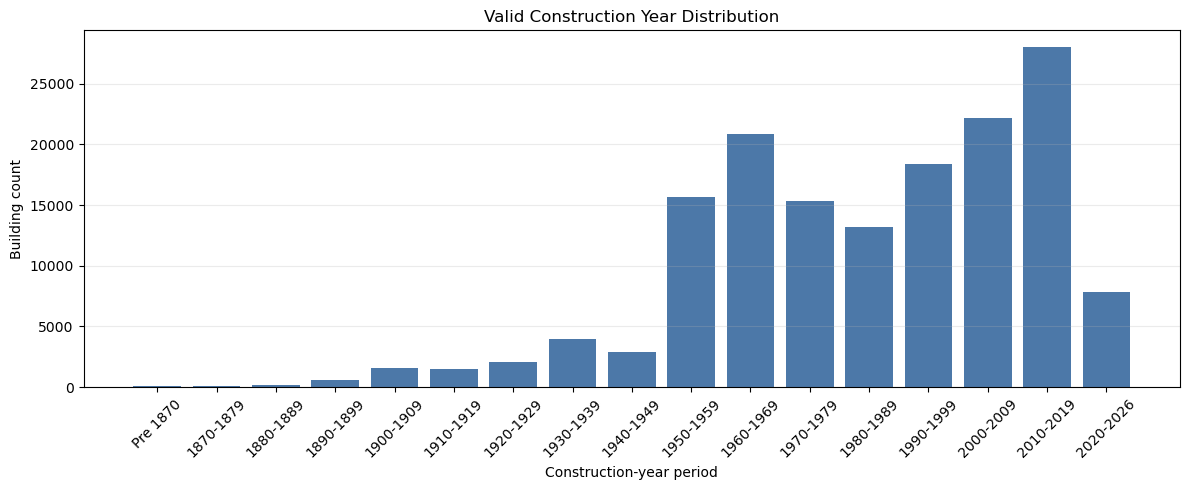

Buildings with valid construction year: 154538
Earliest parsed year: 1550
Latest parsed year: 2023


In [9]:
year_gdf = gdf[gdf["construction_year_available"]].copy()
year_gdf["construction_year"] = year_gdf["construction_year"].astype(int)

PRE_PERIOD_END = 1870

def construction_year_period(year):
    if year < PRE_PERIOD_END:
        return f"Pre {PRE_PERIOD_END}"
    decade_start = year // 10 * 10
    decade_end = min(decade_start + 9, CURRENT_YEAR_MAX)
    return f"{decade_start}-{decade_end}"

year_gdf["construction_year_period"] = year_gdf["construction_year"].apply(construction_year_period)
period_order = [f"Pre {PRE_PERIOD_END}"] + [
    f"{start}-{min(start + 9, CURRENT_YEAR_MAX)}"
    for start in range(PRE_PERIOD_END, CURRENT_YEAR_MAX + 1, 10)
]

year_distribution = (
    year_gdf.groupby("construction_year_period")
    .size()
    .reindex(period_order, fill_value=0)
    .reset_index(name="building_count")
)
year_distribution = year_distribution[year_distribution["building_count"] > 0].copy()
year_distribution["share_of_valid_years_pct"] = (
    year_distribution["building_count"] / len(year_gdf) * 100
).round(2)

display(year_distribution)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    year_distribution["construction_year_period"],
    year_distribution["building_count"],
    color="#4c78a8",
)
ax.set_title("Valid Construction Year Distribution")
ax.set_xlabel("Construction-year period")
ax.set_ylabel("Building count")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("Buildings with valid construction year:", len(year_gdf))
print("Earliest parsed year:", int(year_gdf["construction_year"].min()))
print("Latest parsed year:", int(year_gdf["construction_year"].max()))


## Map: Valid Construction-Year Periods

Map buildings with valid construction years using the same period bins as the distribution above.


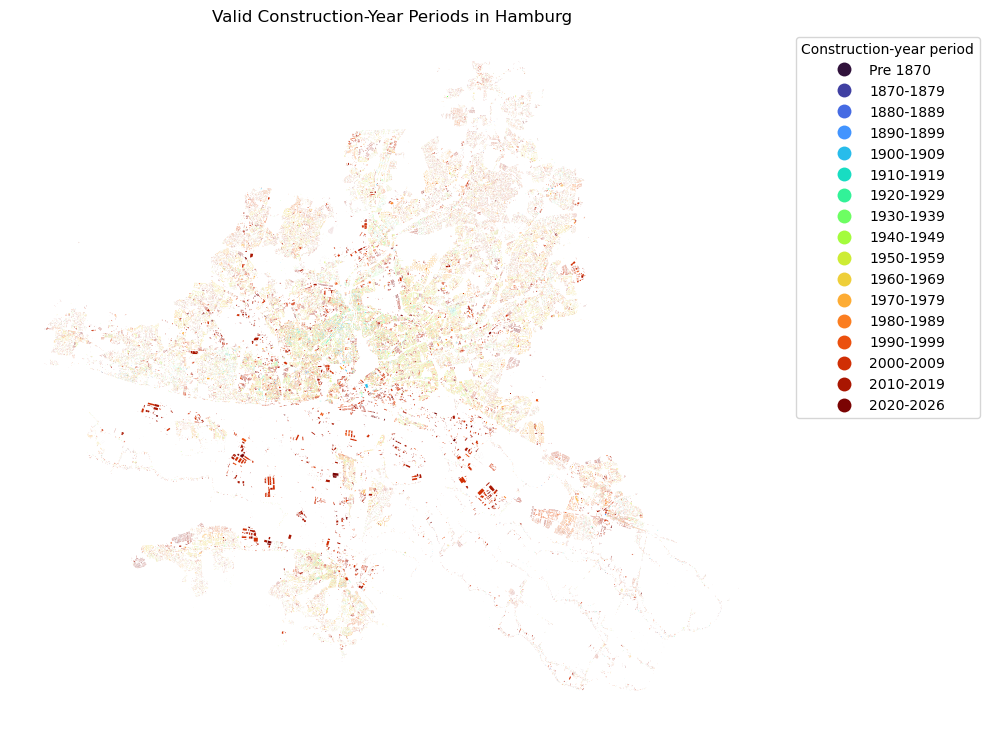

Buildings mapped with valid construction year: 154538
Output: ../results/maps/valid_construction_year_period_map.png


In [10]:
valid_year_map_gdf = gdf[gdf["construction_year_available"]].copy()
valid_year_map_gdf["construction_year"] = valid_year_map_gdf["construction_year"].astype(int)

MAP_PRE_PERIOD_END = 1870

def construction_year_period_for_map(year):
    if year < MAP_PRE_PERIOD_END:
        return f"Pre {MAP_PRE_PERIOD_END}"
    decade_start = year // 10 * 10
    decade_end = min(decade_start + 9, CURRENT_YEAR_MAX)
    return f"{decade_start}-{decade_end}"

period_order_for_map = [f"Pre {MAP_PRE_PERIOD_END}"] + [
    f"{start}-{min(start + 9, CURRENT_YEAR_MAX)}"
    for start in range(MAP_PRE_PERIOD_END, CURRENT_YEAR_MAX + 1, 10)
]
valid_year_map_gdf["construction_year_period"] = valid_year_map_gdf["construction_year"].apply(
    construction_year_period_for_map
)
active_period_order_for_map = [
    period
    for period in period_order_for_map
    if period in set(valid_year_map_gdf["construction_year_period"])
]
valid_year_map_gdf["construction_year_period"] = pd.Categorical(
    valid_year_map_gdf["construction_year_period"],
    categories=active_period_order_for_map,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 10))
valid_year_map_gdf.plot(
    column="construction_year_period",
    categorical=True,
    ax=ax,
    cmap="turbo",
    linewidth=0.02,
    edgecolor="none",
    legend=True,
    legend_kwds={"title": "Construction-year period", "bbox_to_anchor": (1.02, 1), "loc": "upper left"},
)
ax.set_title("Valid Construction-Year Periods in Hamburg")
ax.set_axis_off()
plt.tight_layout()

valid_year_period_map_output_path = MAP_DIR / "valid_construction_year_period_map.png"
plt.savefig(valid_year_period_map_output_path, dpi=500, bbox_inches="tight")
plt.show()

print("Buildings mapped with valid construction year:", len(valid_year_map_gdf))
print("Output:", valid_year_period_map_output_path)


## Storey Distribution

In [11]:
RESIDENTIAL_FUNCTION_LABELS_EN = {
    1010: "Residential building",
    1020: "Dormitory",
    1100: "Mixed-use with residential use",
    1110: "Residential with community facilities",
    1120: "Residential with retail/services",
    1130: "Residential with commerce/industry",
    1210: "Agricultural/forestry residential",
    1220: "Agricultural/forestry residential + operational",
}

storey_gdf = gdf[residential_mask & gdf["valid_storeys"]].copy()
storey_gdf["storeys"] = storey_gdf["storeys_numeric"].astype(int)
storey_gdf["storey_group"] = storey_gdf["storeys"].where(storey_gdf["storeys"].le(10), "10+").astype("string")
storey_gdf["building_function_label_en"] = (
    storey_gdf["building_function"]
    .map(RESIDENTIAL_FUNCTION_LABELS_EN)
    .fillna("Other selected residential function")
)

storey_distribution = (
    storey_gdf
    .groupby(["storeys", "storey_group", "building_function", "building_function_label_en"], dropna=False)
    .size()
    .reset_index(name="building_count")
    .sort_values(["storeys", "building_function"])
)
storey_distribution["share_of_main_residential_stock_pct"] = (
    storey_distribution["building_count"] / int(residential_mask.sum()) * 100
).round(3)

storey_distribution.head(30)


,storeys,storey_group,building_function,building_function_label_en,building_count,share_of_main_residential_stock_pct
0,1,1,1010,Residential building,104726,46.067
1,1,1,1020,Dormitory,203,0.089
2,1,1,1100,Mixed-use with residential use,5170,2.274
3,1,1,1110,Residential with community facilities,12,0.005
4,1,1,1120,Residential with retail/services,1048,0.461
5,1,1,1130,Residential with commerce/industry,221,0.097
6,1,1,1210,Agricultural/forestry residential,483,0.212
7,1,1,1220,Agricultural/forestry residential + operational,331,0.146
8,2,2,1010,Residential building,61340,26.982
9,2,2,1020,Dormitory,568,0.250


## Residential Storey Count Bar Chart

Visualize above-ground storeys only for the selected main residential building stock. The bars are stacked by residential building-function class.


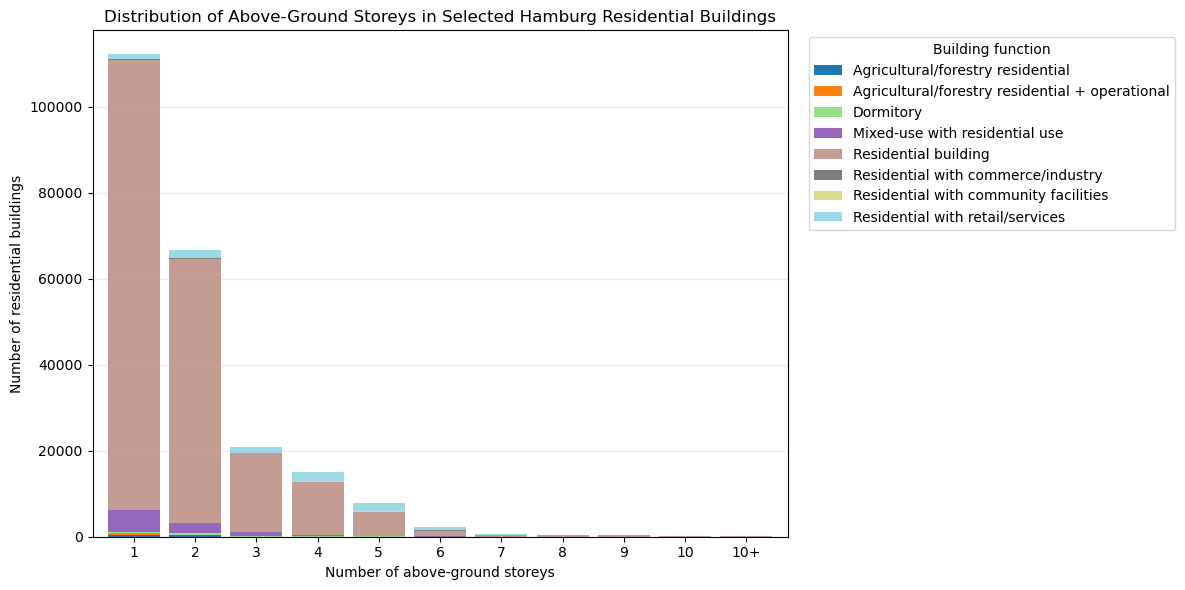

Residential buildings in chart: 227110
Residential buildings missing/invalid storeys, not shown: 224
Output: ../results/maps/residential_storey_count_distribution_stacked_bar.png


In [12]:
storey_stack = storey_distribution.pivot_table(
    index="storey_group",
    columns="building_function_label_en",
    values="building_count",
    aggfunc="sum",
    fill_value=0,
)
storey_order = [str(i) for i in sorted(storey_gdf.loc[storey_gdf["storeys"].le(10), "storeys"].unique())]
if (storey_gdf["storeys"] > 10).any():
    storey_order.append("10+")
storey_stack = storey_stack.reindex(storey_order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
storey_stack.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.85,
    colormap="tab20",
)
ax.set_title("Distribution of Above-Ground Storeys in Selected Hamburg Residential Buildings")
ax.set_xlabel("Number of above-ground storeys")
ax.set_ylabel("Number of residential buildings")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
ax.legend(
    title="Building function",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)
plt.tight_layout()

storey_bar_output_path = MAP_DIR / "residential_storey_count_distribution_stacked_bar.png"
plt.savefig(storey_bar_output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Residential buildings in chart:", int(storey_stack.sum().sum()))
print("Residential buildings missing/invalid storeys, not shown:", int(residential_storeys_missing_or_invalid.sum()))
print("Output:", storey_bar_output_path)


## Map: Residential Above-Ground Storey Count

Map selected residential buildings by valid above-ground storey count. Very tall values are capped in the color scale so normal residential variation remains visible.


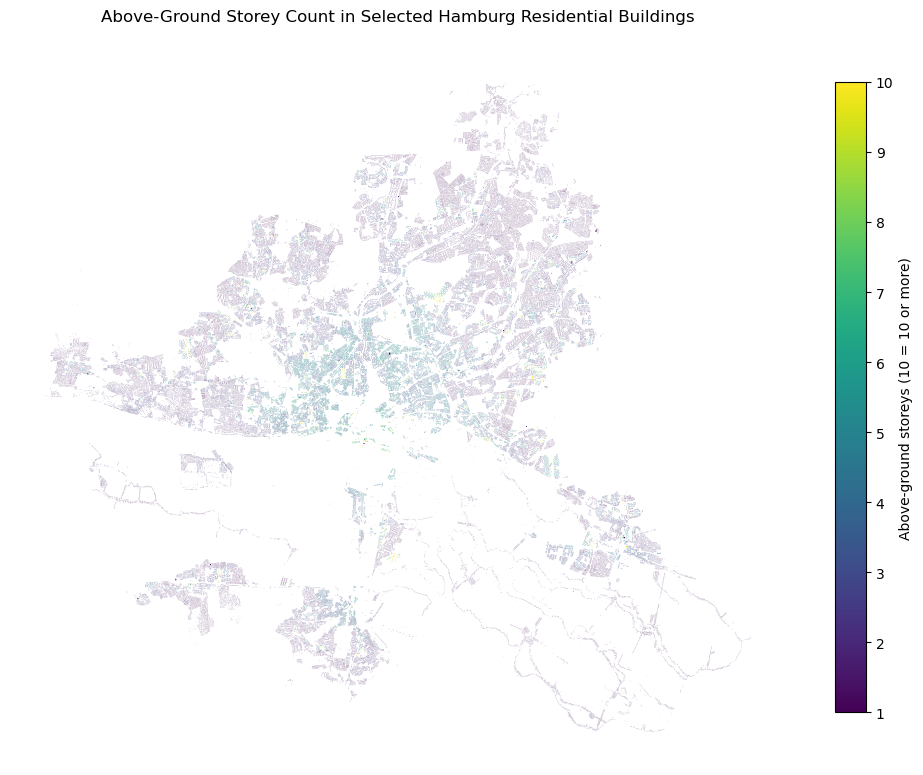

Residential buildings mapped: 227110
Residential buildings missing/invalid storeys, not mapped: 224
Output: ../results/maps/residential_storey_count_map.png


In [13]:
storey_map_gdf = gdf[residential_mask & gdf["valid_storeys"]].copy()
storey_map_gdf["storeys"] = storey_map_gdf["storeys_numeric"].astype(int)
storey_map_gdf["storeys_for_map"] = storey_map_gdf["storeys"].clip(upper=10)

fig, ax = plt.subplots(figsize=(10, 10))
storey_map_gdf.plot(
    column="storeys_for_map",
    ax=ax,
    cmap="viridis",
    linewidth=0.03,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Above-ground storeys (10 = 10 or more)", "shrink": 0.65},
)
ax.set_title("Above-Ground Storey Count in Selected Hamburg Residential Buildings")
ax.set_axis_off()
plt.tight_layout()

storey_map_output_path = MAP_DIR / "residential_storey_count_map.png"
plt.savefig(storey_map_output_path, dpi=500, bbox_inches="tight")
plt.show()

print("Residential buildings mapped:", len(storey_map_gdf))
print("Residential buildings missing/invalid storeys, not mapped:", int(residential_storeys_missing_or_invalid.sum()))
print("Output:", storey_map_output_path)


## Export Intermediate Datasets

In [14]:
gdf_year = gdf[gdf["construction_year_available"]].copy()
gdf_year["construction_year"] = gdf_year["construction_year"].astype(int)
gdf_year.to_file(BUILDINGS_WITH_YEAR_PATH, driver="GPKG")

valid_year_storeys = gdf["construction_year_available"] & gdf["valid_storeys"]
gdf_year_storeys = gdf[valid_year_storeys].copy()
gdf_year_storeys["construction_year"] = gdf_year_storeys["construction_year"].astype(int)
gdf_year_storeys["storeys"] = gdf_year_storeys["storeys_numeric"].astype(int)
gdf_year_storeys.to_file(BUILDINGS_WITH_YEAR_AND_STOREYS_PATH, driver="GPKG")

print("Buildings with construction year:", len(gdf_year))
print("Output:", BUILDINGS_WITH_YEAR_PATH)
print("Buildings with construction year and valid storeys:", len(gdf_year_storeys))
print("Output:", BUILDINGS_WITH_YEAR_AND_STOREYS_PATH)


Buildings with construction year: 154538
Output: ../data/processed/buildings_with_year.gpkg
Buildings with construction year and valid storeys: 153184
Output: ../data/processed/buildings_with_year_and_storeys.gpkg


## Map: Missing Construction Year

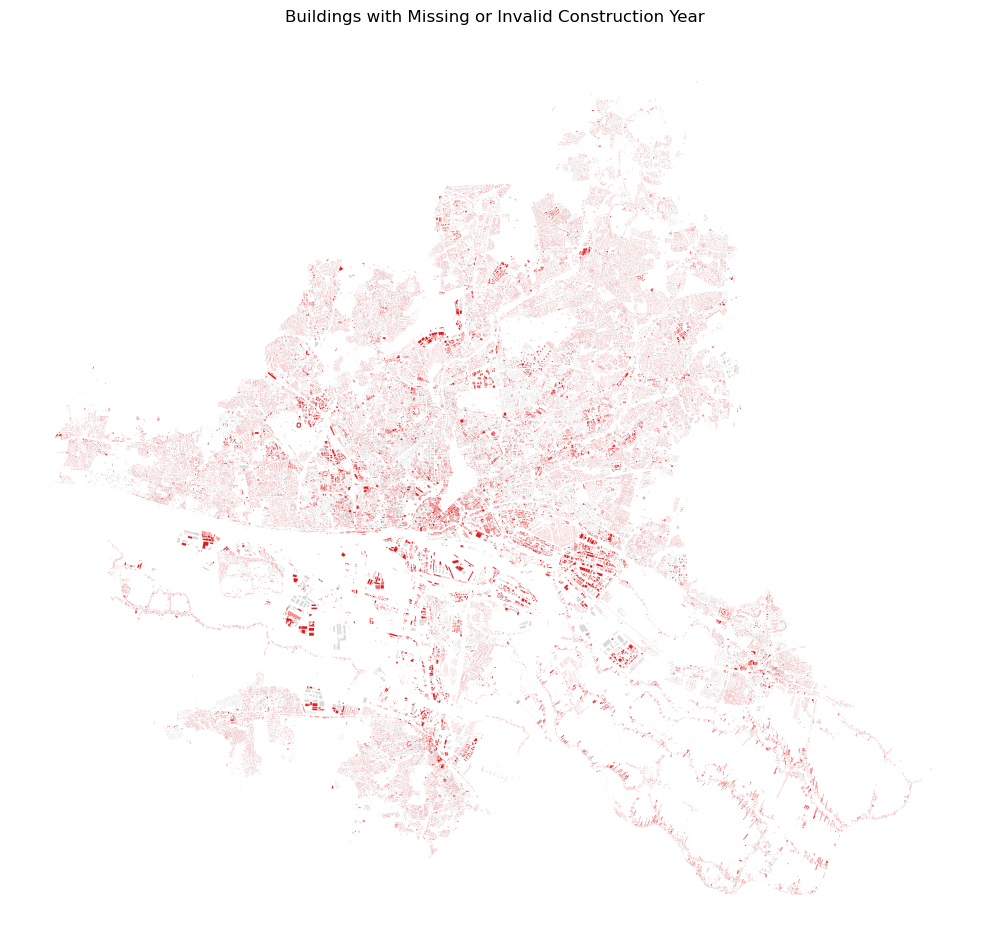

Buildings missing or invalid construction year: 224782
Output: ../results/maps/missing_baujahr_map.png


In [15]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf[gdf["construction_year_available"]].plot(
    ax=ax,
    color="#d9d9d9",
    linewidth=0.05,
    edgecolor="white",
)
gdf[gdf["construction_year_missing"]].plot(
    ax=ax,
    color="#e31a1c",
    linewidth=0.05,
    edgecolor="white",
)
ax.set_title("Buildings with Missing or Invalid Construction Year")
ax.set_axis_off()
plt.tight_layout()

map_output_path = MAP_DIR / "missing_baujahr_map.png"
plt.savefig(map_output_path, dpi=400, bbox_inches="tight")
plt.show()

print("Buildings missing or invalid construction year:", int(gdf["construction_year_missing"].sum()))
print("Output:", map_output_path)


## Map: Buildings with Construction Year Placeholder 1500


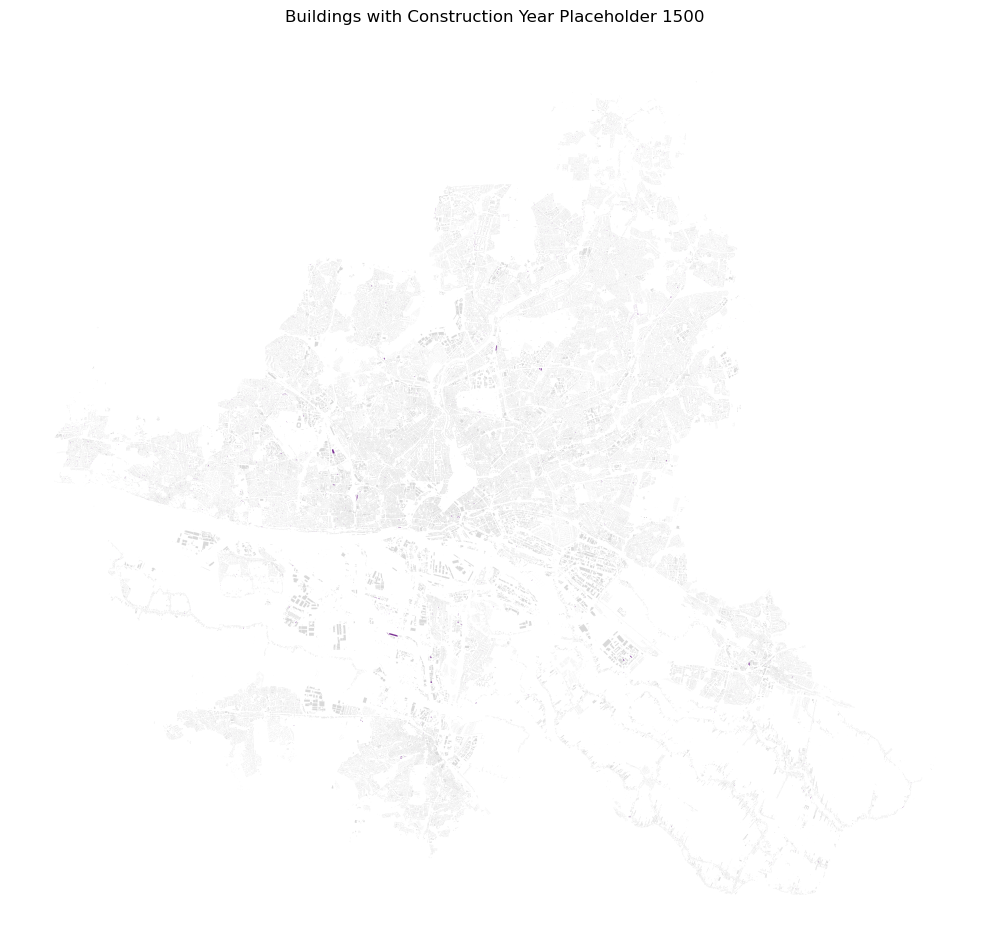

Buildings with construction year placeholder 1500: 2813
Output: ../results/maps/baujahr_1500_map.png


In [16]:
baujahr_1500_mask = gdf["construction_year_status"].eq("invalid_placeholder_1500")
baujahr_1500_gdf = gdf[baujahr_1500_mask].copy()

fig, ax = plt.subplots(figsize=(10, 10))
gdf[~baujahr_1500_mask].plot(
    ax=ax,
    color="#d9d9d9",
    linewidth=0.03,
    edgecolor="white",
)
baujahr_1500_gdf.plot(
    ax=ax,
    color="#7b3294",
    linewidth=0.05,
    edgecolor="white",
)
ax.set_title("Buildings with Construction Year Placeholder 1500")
ax.set_axis_off()
plt.tight_layout()

baujahr_1500_map_output_path = MAP_DIR / "baujahr_1500_map.png"
plt.savefig(baujahr_1500_map_output_path, dpi=400, bbox_inches="tight")
plt.show()

print("Buildings with construction year placeholder 1500:", int(baujahr_1500_mask.sum()))
print("Output:", baujahr_1500_map_output_path)


## Map: Missing or Invalid Storeys

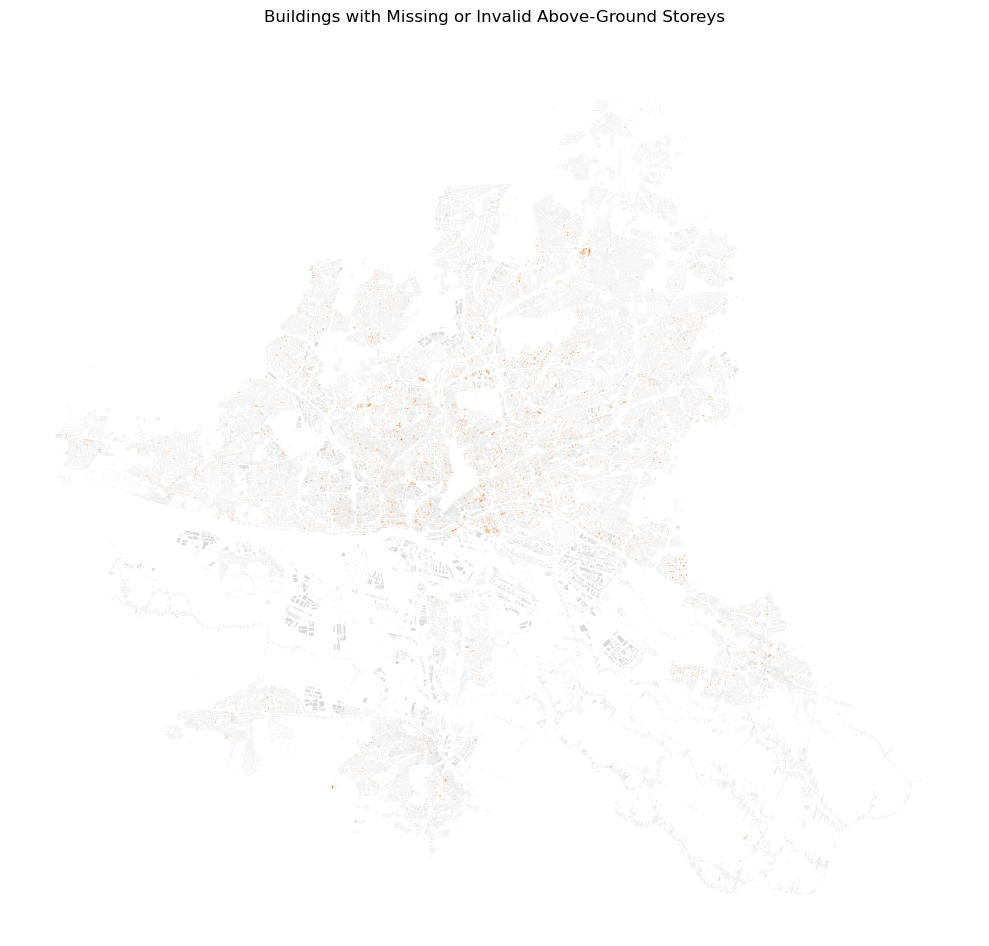

Buildings missing or invalid storeys: 5607
Output: ../results/maps/missing_storeys_map.png


: 

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf[gdf["valid_storeys"]].plot(
    ax=ax,
    color="#d9d9d9",
    linewidth=0.05,
    edgecolor="white",
)
gdf[gdf["storeys_missing_or_invalid"]].plot(
    ax=ax,
    color="#f58518",
    linewidth=0.05,
    edgecolor="white",
)
ax.set_title("Buildings with Missing or Invalid Above-Ground Storeys")
ax.set_axis_off()
plt.tight_layout()

map_output_path = MAP_DIR / "missing_storeys_map.png"
plt.savefig(map_output_path, dpi=400, bbox_inches="tight")
plt.show()

print("Buildings missing or invalid storeys:", int(gdf["storeys_missing_or_invalid"].sum()))
print("Output:", map_output_path)
